In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
df = pd.read_excel(r"FCGR-NML (1).xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SI No.          24 non-null     int64  
 1   Temperature, C  24 non-null     int64  
 2   c               24 non-null     float64
 3   m               24 non-null     float64
 4   ▲ K Range       24 non-null     object 
 5   R- Ratio        24 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 1.3+ KB


In [4]:
df.head(10)

,SI No.,"Temperature, C",c,m,▲ K Range,R- Ratio
0,1,150,8.200000e-09,3.40,14-25,0.1
1,2,150,1.400000e-08,3.30,14-25,0.1
2,3,150,4.700000e-09,3.65,12.0-24,0.1
3,4,150,2.400000e-09,3.93,12.0-23,0.1
4,5,150,5.800000e-08,2.93,11.0-25,0.5
5,6,150,3.800000e-08,3.13,12.0-25,0.5
6,7,150,8.400000e-09,3.67,10.0-22,0.5
7,8,150,1.500000e-09,4.29,11.0-22,0.5
8,9,150,1.900000e-08,3.39,9.0-18,0.7
9,10,150,8.200000e-10,4.98,9.0-12,0.7


In [5]:
print(df.columns.tolist())

['SI No.', 'Temperature, C', 'c ', 'm', '▲ K Range', 'R- Ratio']


In [6]:
# Create a list to hold expanded rows
expanded_rows = []

# Loop through each row
for _, row in df.iterrows():
    # Parse the ΔK range
    try:
        k_range = str(row['▲ K Range']).strip()
        k_min, k_max = map(float, k_range.split('-'))
    except:
        continue

    # Generate integer ΔK values within the range
    delta_k_values = list(range(int(k_min), int(k_max) + 1))

    # Create a new row for each ΔK value
    for delta_k in delta_k_values:
        expanded_rows.append({
            'SI No.': row['SI No.'],
            'Temperature, C': row['Temperature, C'],
            'c': row['c '],
            'm': row['m'],
            'R- Ratio': row['R- Ratio'],
            'Delta K': delta_k
        })

expanded_df = pd.DataFrame(expanded_rows)

expanded_df.head(5)

,SI No.,"Temperature, C",c,m,R- Ratio,Delta K
0,1,150,8.200000e-09,3.4,0.1,14
1,1,150,8.200000e-09,3.4,0.1,15
2,1,150,8.200000e-09,3.4,0.1,16
3,1,150,8.200000e-09,3.4,0.1,17
4,1,150,8.200000e-09,3.4,0.1,18


In [7]:
print(expanded_df.columns.tolist())

['SI No.', 'Temperature, C', 'c', 'm', 'R- Ratio', 'Delta K']


# **Implementation of Paris–Erdoğan equation**

In [8]:
expanded_df["da_dN"] = expanded_df.apply(
    lambda row: row["c"] * ((row["Delta K"]) ** row["m"]),
    axis = 1
)

expanded_df['Temperature,K'] = expanded_df.apply(
    lambda row: row['Temperature, C'] + 273.15,
    axis = 1
)

expanded_df.head(5)

,SI No.,"Temperature, C",c,m,R- Ratio,Delta K,da_dN,"Temperature,K"
0,1,150,8.200000e-09,3.4,0.1,14,0.000065,423.15
1,1,150,8.200000e-09,3.4,0.1,15,0.000082,423.15
2,1,150,8.200000e-09,3.4,0.1,16,0.000102,423.15
3,1,150,8.200000e-09,3.4,0.1,17,0.000125,423.15
4,1,150,8.200000e-09,3.4,0.1,18,0.000152,423.15


# Model

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

features = ['Temperature,K']
target = 'm'
X = expanded_df[features]
y = expanded_df[target]


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Evaluate
y_pred = linear_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nLinear Fit RMSE on m: {rmse:.4f}")

lin_intercept = linear_model.intercept_
lin_slope = linear_model.coef_[0]
print(f"intercept: {lin_intercept:}, slope: {lin_slope:}")

# Predict full set
X_full = expanded_df[['Temperature,K']]
expanded_df['M'] = linear_model.predict(X_full)

expanded_df[['Temperature,K', 'm', 'M']].head()


Linear Fit RMSE on m: 0.4150
intercept: 3.696436065766185, slope: -0.000480326657351343


,"Temperature,K",m,M
0,423.15,3.4,3.493186
1,423.15,3.4,3.493186
2,423.15,3.4,3.493186
3,423.15,3.4,3.493186
4,423.15,3.4,3.493186


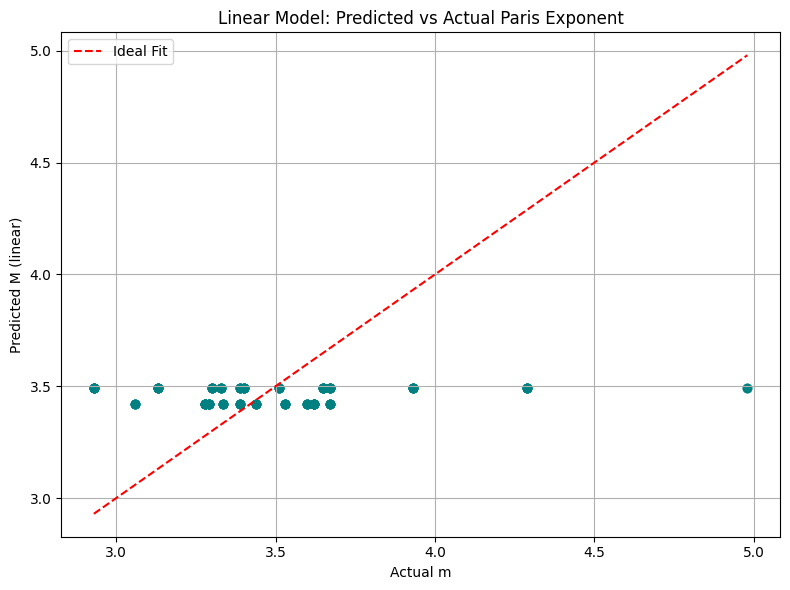

In [11]:
# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(expanded_df['m'], expanded_df['M'], alpha=0.6, color='teal')
plt.plot([expanded_df['m'].min(), expanded_df['m'].max()],
         [expanded_df['m'].min(), expanded_df['m'].max()],
         'r--', label='Ideal Fit')
plt.xlabel('Actual m')
plt.ylabel('Predicted M (linear)')
plt.title('Linear Model: Predicted vs Actual Paris Exponent')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Implementation of Walker Equation

In [12]:
expanded_df["y"] = expanded_df.apply(
    lambda row: np.log(row["da_dN"]) - (row["M"] * np.log(row["Delta K"])),
    axis = 1
)

expanded_df['x'] = expanded_df.apply(
    lambda row: row["M"] * np.log(1 - row["R- Ratio"]),
    axis = 1
)

expanded_df.head(5)

,SI No.,"Temperature, C",c,m,R- Ratio,Delta K,da_dN,"Temperature,K",M,y,x
0,1,150,8.200000e-09,3.4,0.1,14,0.000065,423.15,3.493186,-18.865054,-0.368044
1,1,150,8.200000e-09,3.4,0.1,15,0.000082,423.15,3.493186,-18.871484,-0.368044
2,1,150,8.200000e-09,3.4,0.1,16,0.000102,423.15,3.493186,-18.877498,-0.368044
3,1,150,8.200000e-09,3.4,0.1,17,0.000125,423.15,3.493186,-18.883147,-0.368044
4,1,150,8.200000e-09,3.4,0.1,18,0.000152,423.15,3.493186,-18.888473,-0.368044


In [13]:
def lin_reg(X, Y):
    # Compute means
    X_mean = sum(X) / len(X)
    Y_mean = sum(Y) / len(Y)
    
    # Compute slope
    numerator = sum((X[i] - X_mean) * (Y[i] - Y_mean) for i in range(len(X)))
    denominator = sum((X[i] - X_mean) ** 2 for i in range(len(X)))
    slope = numerator / denominator
    
    # Compute intercept
    intercept = Y_mean - slope * X_mean

    return slope, intercept

slope, intercept = lin_reg(expanded_df['x'], expanded_df["y"])
print(f"slope: {slope:.4f} ,\nintercept: {intercept:.4f}")

slope: -0.2138 ,
intercept: -18.6962


<Figure size 800x600 with 0 Axes>

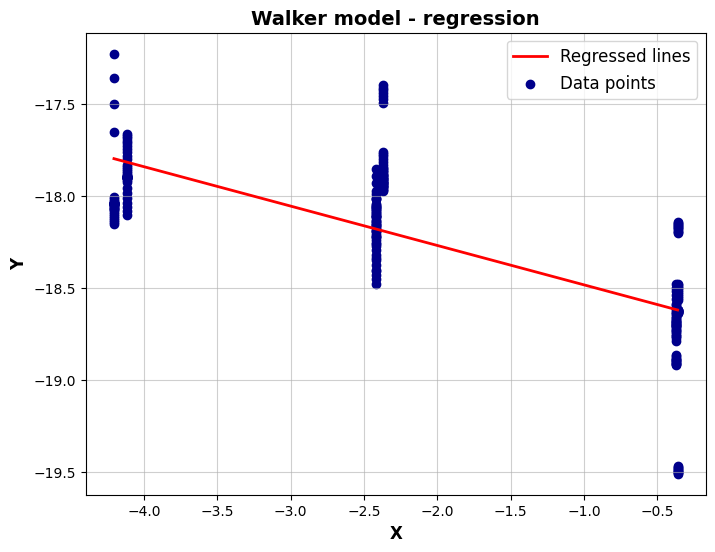

In [14]:
plt.figure(figsize=(8, 6))
x_values = np.linspace(expanded_df['x'].min(), expanded_df['x'].max(), 100)

y_values = (
    slope * x_values + intercept
)

plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, color="red", linestyle="-", linewidth=2, label="Regressed lines")
plt.scatter(expanded_df['x'], expanded_df['y'], color="darkblue", label="Data points")

plt.xlabel("X", fontsize=12, fontweight="bold")
plt.ylabel("Y", fontsize=12, fontweight="bold")
plt.title("Walker model - regression", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="-", alpha=0.6)
plt.legend(fontsize=12)

plt.show()

In [15]:
C = np.exp(intercept)
gamma = slope

C, gamma

(np.float64(7.591589604729075e-09), np.float64(-0.21377988642479592))

In [16]:
expanded_df['da/dN_calc'] = expanded_df.apply(
    lambda row: C * ((row["Delta K"] * ((1 - row["R- Ratio"])** gamma)) ** row["M"]),
    axis = 1
)

expanded_df.head(5)

,SI No.,"Temperature, C",c,m,R- Ratio,Delta K,da_dN,"Temperature,K",M,y,x,da/dN_calc
0,1,150,8.200000e-09,3.4,0.1,14,0.000065,423.15,3.493186,-18.865054,-0.368044,0.000083
1,1,150,8.200000e-09,3.4,0.1,15,0.000082,423.15,3.493186,-18.871484,-0.368044,0.000105
2,1,150,8.200000e-09,3.4,0.1,16,0.000102,423.15,3.493186,-18.877498,-0.368044,0.000132
3,1,150,8.200000e-09,3.4,0.1,17,0.000125,423.15,3.493186,-18.883147,-0.368044,0.000163
4,1,150,8.200000e-09,3.4,0.1,18,0.000152,423.15,3.493186,-18.888473,-0.368044,0.000199


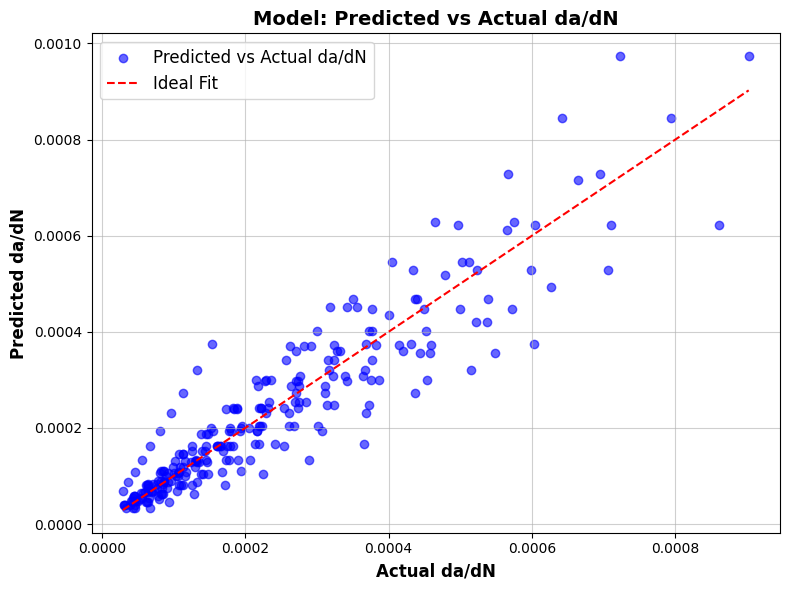

In [17]:
actual = expanded_df['da_dN']
predicted = expanded_df['da/dN_calc']

plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, color='blue', alpha=0.6, label='Predicted vs Actual da/dN')

# Reference line (perfect prediction)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', label='Ideal Fit')

plt.xlabel('Actual da/dN', fontsize=12, fontweight='bold')
plt.ylabel('Predicted da/dN', fontsize=12, fontweight='bold')
plt.title('Model: Predicted vs Actual da/dN', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()
plt.show()

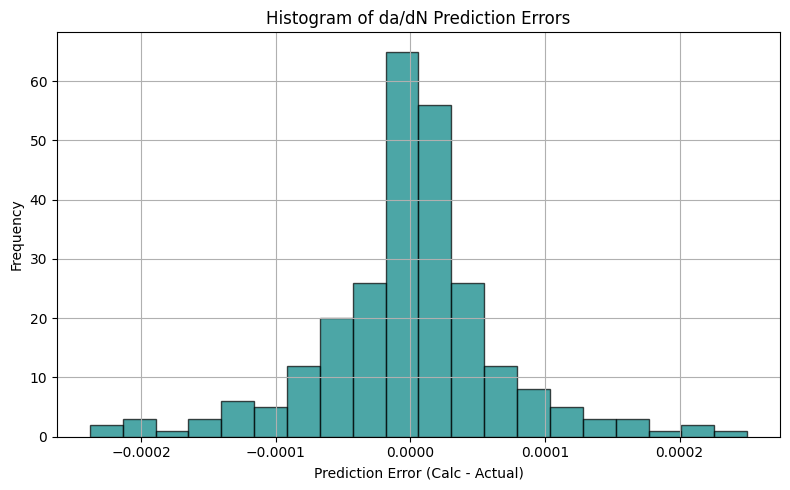

In [18]:
error = expanded_df["da/dN_calc"] - expanded_df["da_dN"]

plt.figure(figsize=(8, 5))
plt.hist(error, bins=20, color='teal', edgecolor='black', alpha=0.7)

plt.xlabel('Prediction Error (Calc - Actual)')
plt.ylabel('Frequency')
plt.title('Histogram of da/dN Prediction Errors')
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
def compute_M(temp_C, intercept, slope):
    temp_K = temp_C + 273.15
    M_val = intercept + (slope * temp_K)
    return M_val
    
def plot_da_dN_vs_deltaK_equation(temp_C, r_ratio, C, gamma, intercept, slope):
    delta_K_vals = np.linspace(5, 40, 200)
    da_dN_vals = []

    M = compute_M(temp_C, intercept, slope)

    for dk in delta_K_vals:
        da_dN = C * ((dk * (1 - r_ratio) ** gamma) ** M)
        da_dN_vals.append(da_dN)

    scatter_df = expanded_df[
        (expanded_df['Temperature, C'] == temp_C) &
        (np.isclose(expanded_df['R- Ratio'], r_ratio, rtol=1e-2))
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(delta_K_vals, da_dN_vals, label='Predicted by Equation', color='darkorange')
    if not scatter_df.empty:
        plt.scatter(scatter_df['Delta K'], scatter_df['da_dN'], label='Actual data', color='navy')
    plt.xlabel('ΔK')
    plt.ylabel('da/dN')
    plt.title(f'da/dN vs ΔK at T={temp_C}°C, R={r_ratio}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

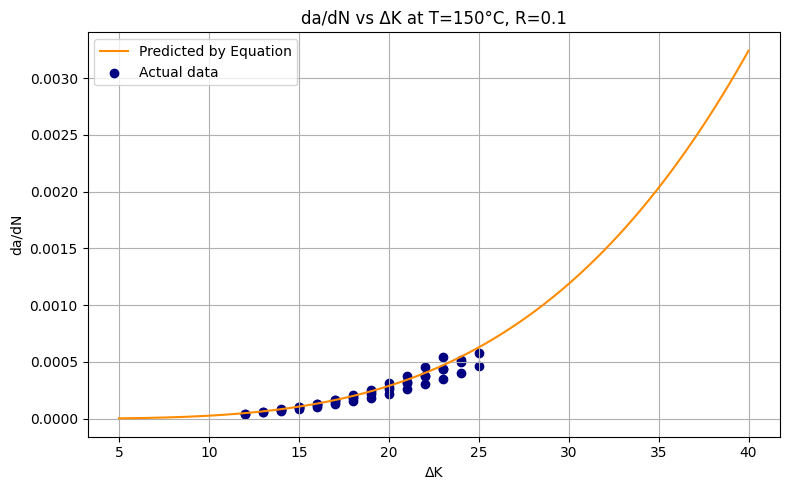

In [37]:
plot_da_dN_vs_deltaK_equation(temp_C=150, r_ratio=0.1, C=C, gamma=gamma, intercept=lin_intercept, slope=lin_slope)

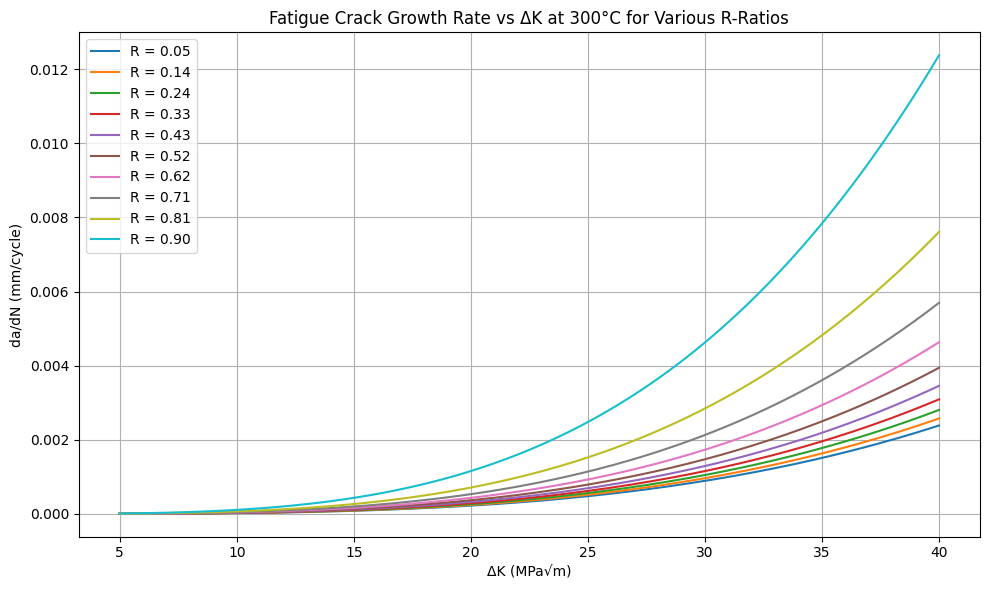

In [21]:
r_ratio_vals = np.linspace(0.05, 0.9, 10)
delta_K_range = np.linspace(5, 40, 200)
temp_C = 300

plt.figure(figsize=(10, 6))

for r in r_ratio_vals:
    da_dN_vals = []
    for dk in delta_K_range:
        M = compute_M(temp_C, lin_intercept, lin_slope)
        base = dk * (max(1e-8, (1 - r)) ** gamma)  # epsilon to prevent divide-by-zero
        da_dN = C * (base ** M)
        da_dN_vals.append(da_dN)

    plt.plot(delta_K_range, da_dN_vals, label=f'R = {r:.2f}')

    scatter_df = expanded_df[
        (expanded_df['Temperature, C'] == temp_C) &
        (np.isclose(expanded_df['R- Ratio'], r, rtol=1e-2))
    ]
    if not scatter_df.empty:
        plt.scatter(scatter_df['Delta K'], scatter_df['da_dN'], label=f'Actual R={r:.2f}', alpha=0.5)

plt.xlabel('ΔK (MPa√m)')
plt.ylabel('da/dN (mm/cycle)')
plt.title(f'Fatigue Crack Growth Rate vs ΔK at {temp_C}°C for Various R-Ratios')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

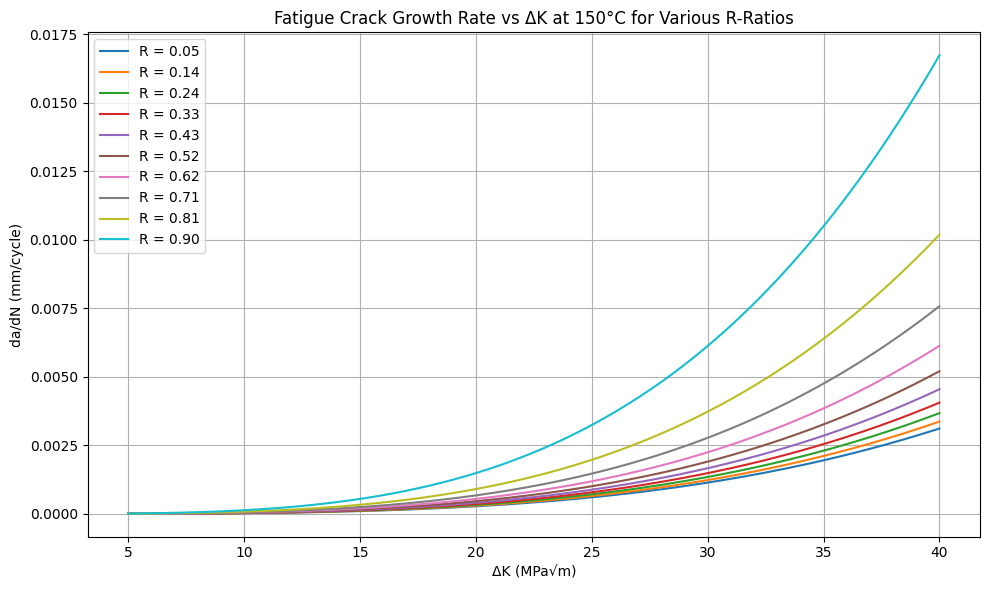

In [22]:
r_ratio_vals = np.linspace(0.05, 0.9, 10)
delta_K_range = np.linspace(5, 40, 200)
temp_C = 150

plt.figure(figsize=(10, 6))

for r in r_ratio_vals:
    da_dN_vals = []
    for dk in delta_K_range:
        M = compute_M(temp_C, lin_intercept, lin_slope)
        base = dk * (max(1e-8, (1 - r)) ** gamma)  # epsilon to prevent divide-by-zero
        da_dN = C * (base ** M)
        da_dN_vals.append(da_dN)

    plt.plot(delta_K_range, da_dN_vals, label=f'R = {r:.2f}')

    scatter_df = expanded_df[
        (expanded_df['Temperature, C'] == temp_C) &
        (np.isclose(expanded_df['R- Ratio'], r, rtol=1e-2))
    ]
    if not scatter_df.empty:
        plt.scatter(scatter_df['Delta K'], scatter_df['da_dN'], label=f'Actual R={r:.2f}', alpha=0.5)

plt.xlabel('ΔK (MPa√m)')
plt.ylabel('da/dN (mm/cycle)')
plt.title(f'Fatigue Crack Growth Rate vs ΔK at {temp_C}°C for Various R-Ratios')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
def plot_da_dN_vs_r_ratio_equation(temp_C, delta_K, C, gamma, intercept, slope):
    r_ratio_vals = np.linspace(0.05, 1, 200)
    da_dN_vals = []
    dk = delta_K

    for r in r_ratio_vals:
        M = compute_M(temp_C, intercept, slope)
        da_dN = C * ((dk * (1 - r) ** gamma) ** M)
        da_dN_vals.append(da_dN)

    scatter_df = expanded_df[
        (expanded_df['Temperature, C'] == temp_C) &
        (np.isclose(expanded_df['Delta K'], dk, rtol=1e-2))
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(r_ratio_vals, da_dN_vals, label='Predicted by Equation', color='darkorange')
    if not scatter_df.empty:
        plt.scatter(scatter_df['R- Ratio'], scatter_df['da_dN'], label='Actual data', color='navy')
    plt.xlabel('R-Ratio')
    plt.ylabel('da/dN')
    plt.title(f'da/dN vs R at T={temp_C}°C, ΔK={delta_K}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

C:\Users\Chiranjeeb Debata\AppData\Local\Temp\ipykernel_36600\864677778.py:8: RuntimeWarning: divide by zero encountered in scalar power
  da_dN = C * ((dk * (1 - r) ** gamma) ** M)


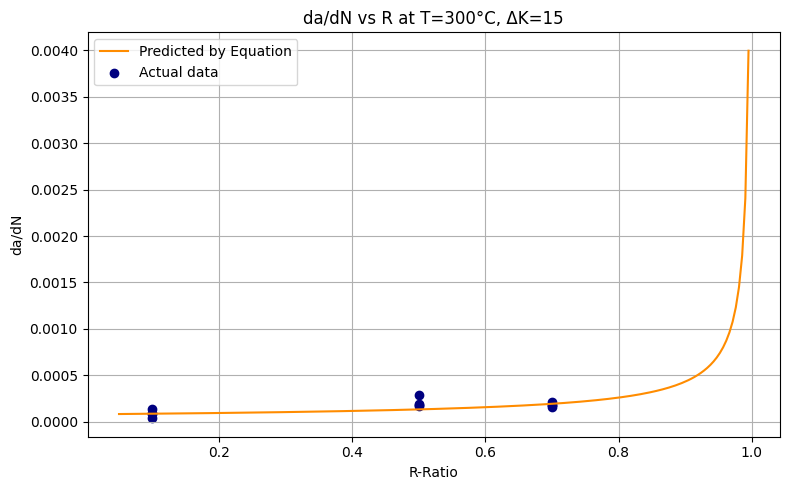

In [24]:
plot_da_dN_vs_r_ratio_equation(temp_C=300, delta_K = 15, C=C, gamma=gamma, intercept= lin_intercept, slope=lin_slope)

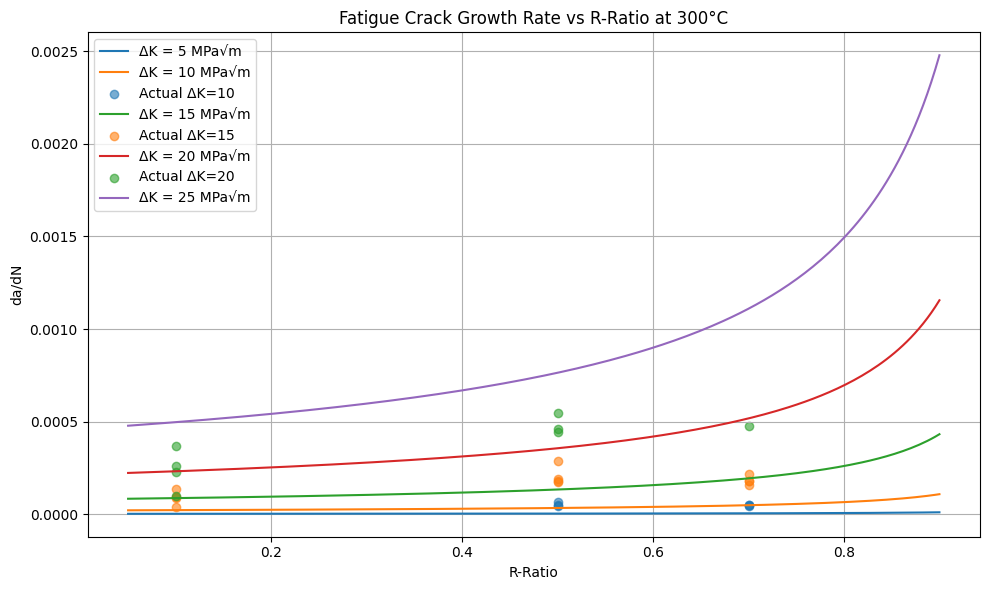

In [25]:
delta_K_vals = [5, 10, 15, 20, 25]
temp_C = 300

plt.figure(figsize=(10, 6))  # One unified figure

r_ratio_vals = np.linspace(0.05, 0.9, 200)

for dk in delta_K_vals:
    da_dN_vals = []
    for r in r_ratio_vals:
        M = compute_M(temp_C, lin_intercept, lin_slope)
        da_dN = C * ((dk * (1 - r) ** gamma) ** M)
        da_dN_vals.append(da_dN)

    plt.plot(r_ratio_vals, da_dN_vals, label=f'ΔK = {dk} MPa√m')

    # Optionally overlay actual data points
    scatter_df = expanded_df[
        (expanded_df['Temperature, C'] == temp_C) &
        (np.isclose(expanded_df['Delta K'], dk, rtol=1e-2))
    ]
    if not scatter_df.empty:
        plt.scatter(scatter_df['R- Ratio'], scatter_df['da_dN'], label=f'Actual ΔK={dk}', alpha=0.6)

# Plot styling
plt.xlabel('R-Ratio')
plt.ylabel('da/dN')
plt.title(f'Fatigue Crack Growth Rate vs R-Ratio at {temp_C}°C')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

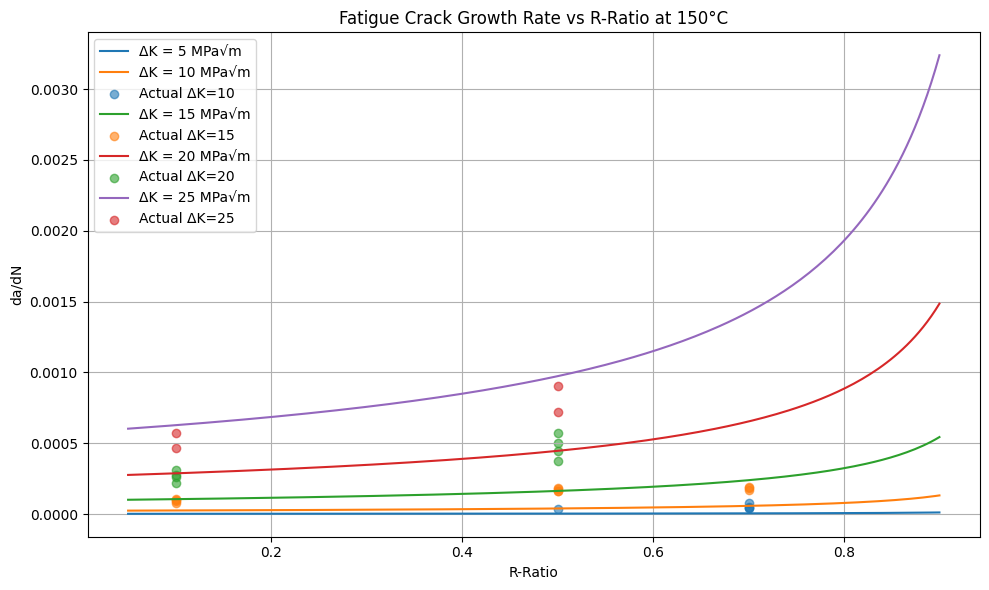

In [26]:
delta_K_vals = [5, 10, 15, 20, 25]
temp_C = 150

plt.figure(figsize=(10, 6))  # One unified figure

r_ratio_vals = np.linspace(0.05, 0.9, 200)

for dk in delta_K_vals:
    da_dN_vals = []
    for r in r_ratio_vals:
        M = compute_M(temp_C, lin_intercept, lin_slope)
        da_dN = C * ((dk * (1 - r) ** gamma) ** M)
        da_dN_vals.append(da_dN)

    plt.plot(r_ratio_vals, da_dN_vals, label=f'ΔK = {dk} MPa√m')

    # Optionally overlay actual data points
    scatter_df = expanded_df[
        (expanded_df['Temperature, C'] == temp_C) &
        (np.isclose(expanded_df['Delta K'], dk, rtol=1e-2))
    ]
    if not scatter_df.empty:
        plt.scatter(scatter_df['R- Ratio'], scatter_df['da_dN'], label=f'Actual ΔK={dk}', alpha=0.6)

# Plot styling
plt.xlabel('R-Ratio')
plt.ylabel('da/dN')
plt.title(f'Fatigue Crack Growth Rate vs R-Ratio at {temp_C}°C')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
def plot_da_dN_vs_temperature_equation(delta_K, r_ratio, C, gamma, intercept, slope):
    temp_vals = np.linspace(50, 300, 300)
    da_dN_vals = []
    dk = delta_K

    for temp_C in temp_vals:
        M = compute_M(temp_C, intercept, slope)
        da_dN = C * ((dk * (1 - r_ratio) ** gamma) ** M)
        da_dN_vals.append(da_dN)

    scatter_df = expanded_df[
        (np.isclose(expanded_df['Delta K'], dk, rtol=1e-2)) &
        (np.isclose(expanded_df['R- Ratio'], r_ratio, rtol=1e-2))
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(temp_vals, da_dN_vals, label='Predicted by Equation', color='darkorange')
    if not scatter_df.empty:
        plt.scatter(scatter_df['Temperature, C'], scatter_df['da_dN'], label='Actual data', color='navy')
    plt.xlabel('Temperature, C')
    plt.ylabel('da/dN')
    plt.title(f'da/dN vs T(°C) at ΔK={delta_K}, R={r_ratio}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

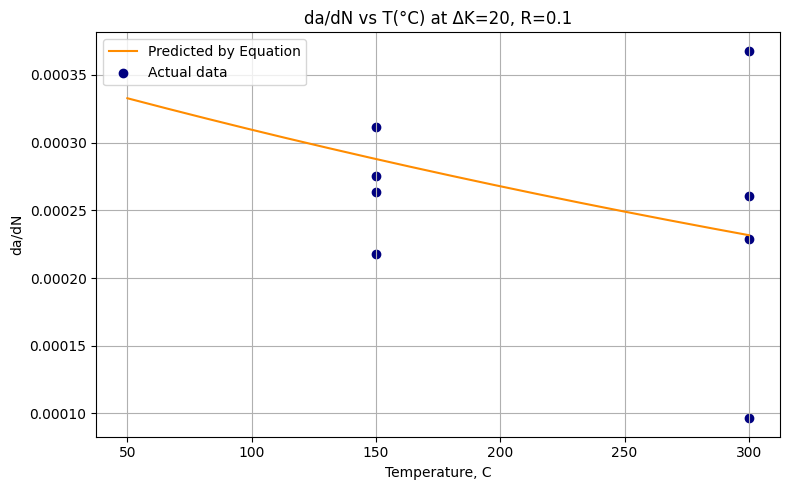

In [28]:
plot_da_dN_vs_temperature_equation(delta_K = 20, r_ratio = 0.1, C=C, gamma=gamma, intercept=lin_intercept, slope=lin_slope)

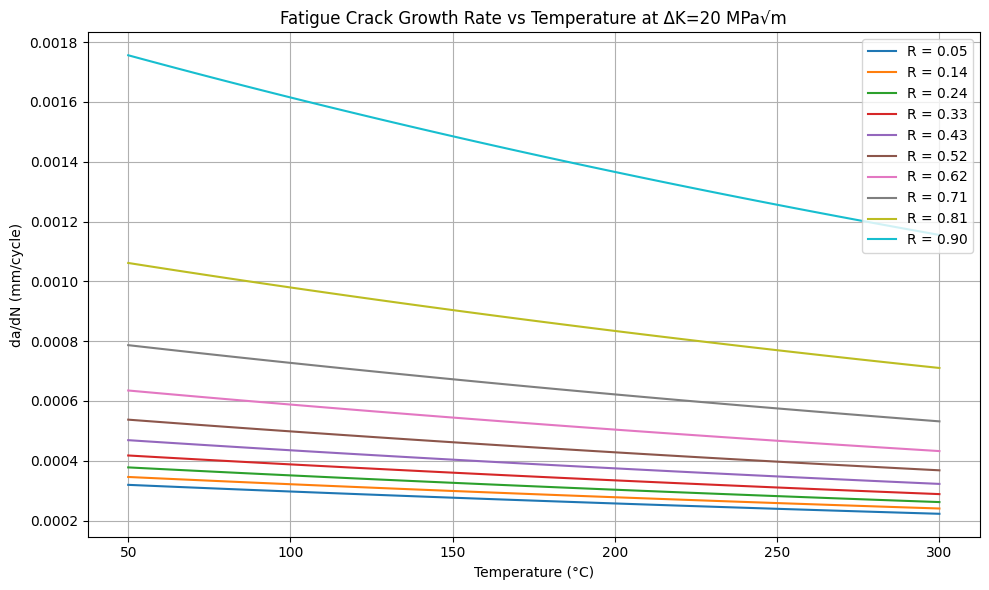

In [29]:
r_ratio_vals = np.linspace(0.05, 0.9, 10)  # Adjust for resolution as needed
temp_vals = np.linspace(50, 300, 50)
delta_K = 20  # Fixed ΔK value (can sweep separately if needed)

plt.figure(figsize=(10, 6))

for r in r_ratio_vals:
    da_dN_vals = []
    for temp_C in temp_vals:
        M = compute_M(temp_C, lin_intercept, lin_slope)
        base = delta_K * (max(1e-8, (1 - r)) ** gamma)  # Avoid divide-by-zero
        da_dN = C * (base ** M)
        da_dN_vals.append(da_dN)

    plt.plot(temp_vals, da_dN_vals, label=f'R = {r:.2f}')

    scatter_df = expanded_df[
        (np.isclose(expanded_df['Delta K'], delta_K, rtol=1e-2)) &
        (np.isclose(expanded_df['R- Ratio'], r, rtol=1e-2))
    ]
    if not scatter_df.empty:
        plt.scatter(scatter_df['Temperature, C'], scatter_df['da_dN'], label=f'Actual R={r:.2f}', alpha=0.6)

plt.xlabel('Temperature (°C)')
plt.ylabel('da/dN (mm/cycle)')
plt.title(f'Fatigue Crack Growth Rate vs Temperature at ΔK={delta_K} MPa√m')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()